# NVIDIA STOCK ANALYTICS & PREDICTIONS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nvidia_raw = pd.read_csv('Nvidia_Stock_data.csv')

In [3]:
nvidia = nvidia_raw.copy()

In [4]:
nvidia.tail()

,Date,Close,High,Low,Open,Volume
6791,2026-01-22,184.839996,186.169998,183.929993,184.750000,139636600
6792,2026-01-23,187.669998,189.600006,186.820007,187.500000,142748100
6793,2026-01-26,186.470001,189.119995,185.990005,187.160004,124799600
6794,2026-01-27,188.520004,190.000000,185.699997,187.240005,143711600
6795,2026-01-28,191.520004,192.350006,189.839996,191.270004,147338800


In [5]:
nvidia.shape

(6796, 6)

In [4]:
nvidia['Date'] = pd.to_datetime(nvidia['Date'])

In [7]:
nvidia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6796 entries, 0 to 6795
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6796 non-null   datetime64[ns]
 1   Close   6796 non-null   float64       
 2   High    6796 non-null   float64       
 3   Low     6796 non-null   float64       
 4   Open    6796 non-null   float64       
 5   Volume  6796 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 318.7 KB


In [8]:
nvidia.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
nvidia.duplicated().sum()

np.int64(0)

In [5]:
nvidia.set_index('Date', inplace=True)

In [11]:
nvidia.head()

,Close,High,Low,Open,Volume
Date,,,,,
1999-01-22,0.037605,0.044767,0.035575,0.040112,2714688000
1999-01-25,0.041545,0.042021,0.037605,0.040589,510480000
1999-01-26,0.038321,0.042857,0.037724,0.042021,343200000
1999-01-27,0.038202,0.039395,0.036291,0.038440,244368000
1999-01-28,0.038082,0.038440,0.037843,0.038202,227520000


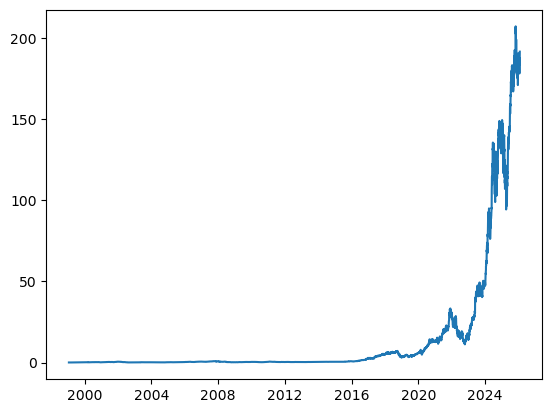

In [12]:
plt.plot(nvidia['Close'])

## Feature Engineering

In [6]:
nvidia['Returns'] = nvidia['Close'].pct_change()

In [30]:
nvidia.head()

,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility
Date,,,,,,,,,
1999-01-22,0.037605,0.044767,0.035575,0.040112,2714688000,NaN,NaN,NaN,NaN
1999-01-25,0.041545,0.042021,0.037605,0.040589,510480000,0.104764,NaN,NaN,NaN
1999-01-26,0.038321,0.042857,0.037724,0.042021,343200000,-0.077593,NaN,NaN,NaN
1999-01-27,0.038202,0.039395,0.036291,0.038440,244368000,-0.003110,NaN,NaN,NaN
1999-01-28,0.038082,0.038440,0.037843,0.038202,227520000,-0.003144,NaN,NaN,NaN


### Moving averages

In [7]:
nvidia['MA20'] = nvidia['Close'].rolling(window=20).mean()

In [8]:
nvidia['MA50'] = nvidia['Close'].rolling(window=50).mean()

In [9]:
nvidia['Volatility'] = nvidia['Returns'].rolling(window=20).std()

## Univariaty Analysis

#### Closing Price Distribution

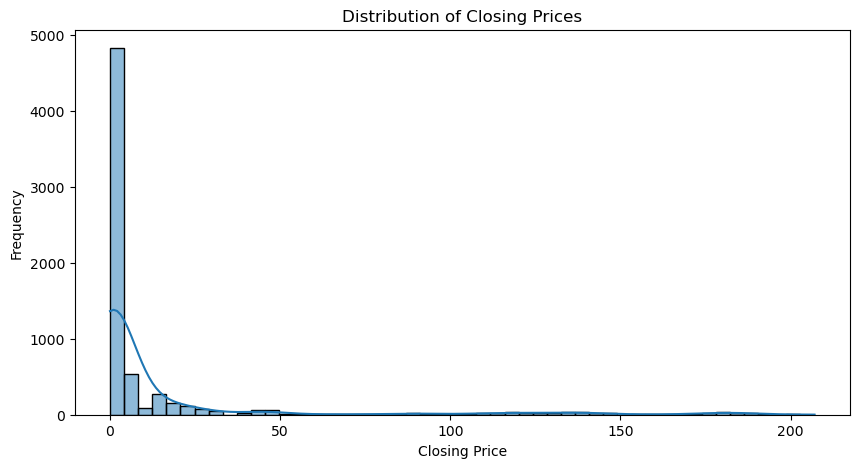

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(nvidia['Close'], bins=50, kde=True)

plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.show()

## Time Series Analysis

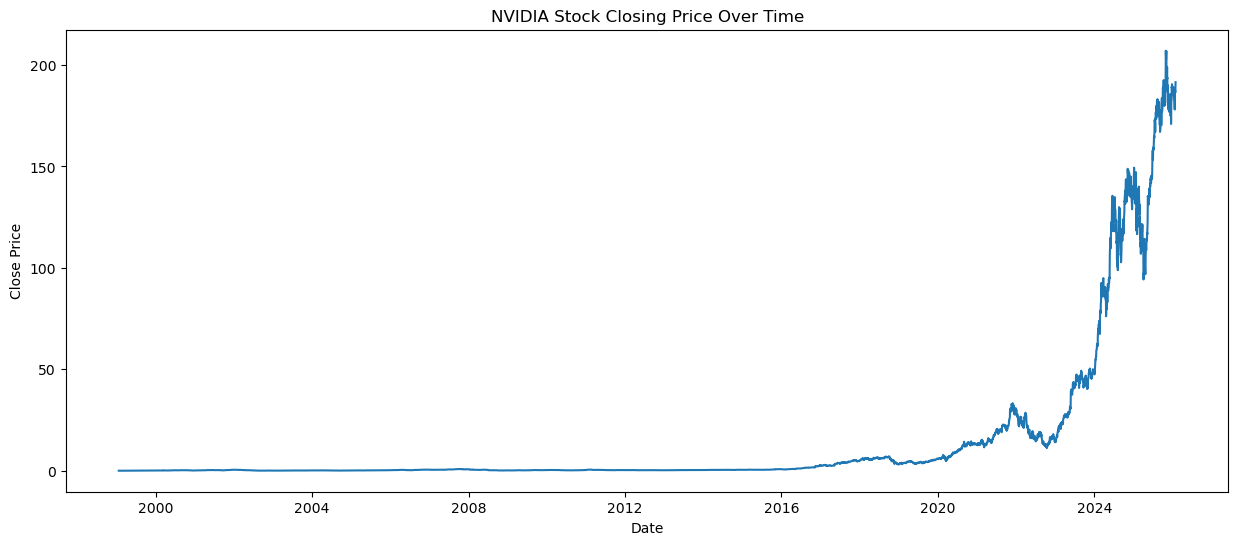

In [34]:
plt.figure(figsize=(15,6))

plt.plot(nvidia.index, nvidia['Close'])

plt.title('NVIDIA Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.show()

## Moving Average Analysis

In [26]:
recent_data = nvidia.loc['2020':]

rrecent_data = nvidia.loc['2023':]

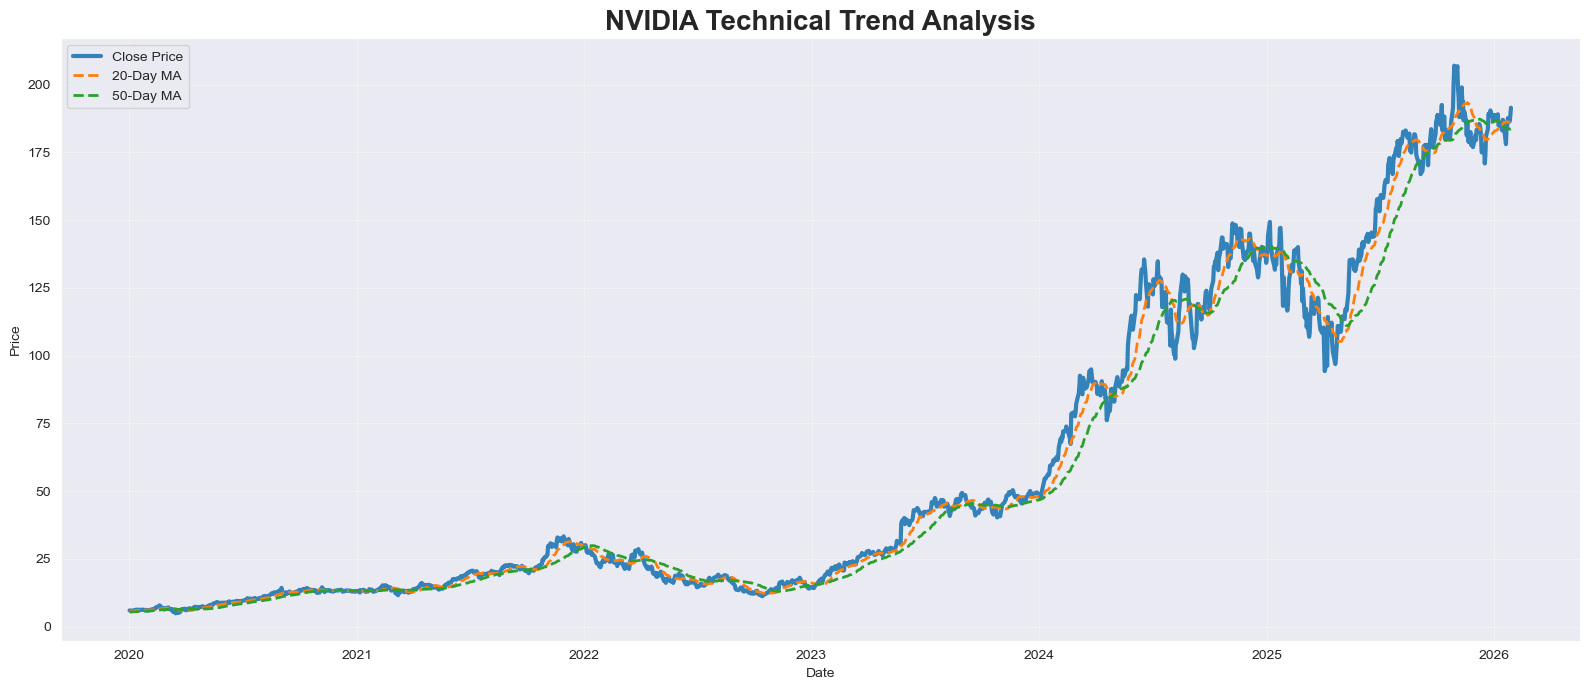

In [43]:
plt.figure(figsize=(16,7))

plt.plot(recent_data.index,
         recent_data['Close'],
         linewidth=3,
         alpha=0.9,
         label='Close Price')

plt.plot(recent_data.index,
         recent_data['MA20'],
         linewidth=2,
         linestyle='--',
         label='20-Day MA')

plt.plot(recent_data.index,
         recent_data['MA50'],
         linewidth=2,
         linestyle='--',
         label='50-Day MA')

plt.title('NVIDIA Technical Trend Analysis',
          fontsize=20,
          fontweight='bold')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Daily Returns Distribution

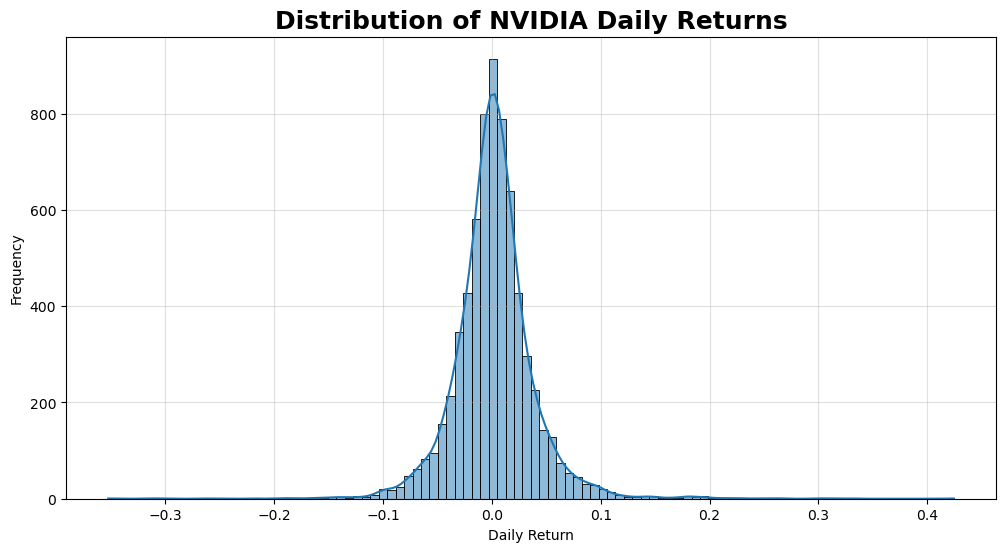

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    nvidia['Returns'].dropna(),
    bins=100,
    kde=True
)

plt.title('Distribution of NVIDIA Daily Returns',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.grid(alpha=0.4)

plt.show()

### Volatality Analysis

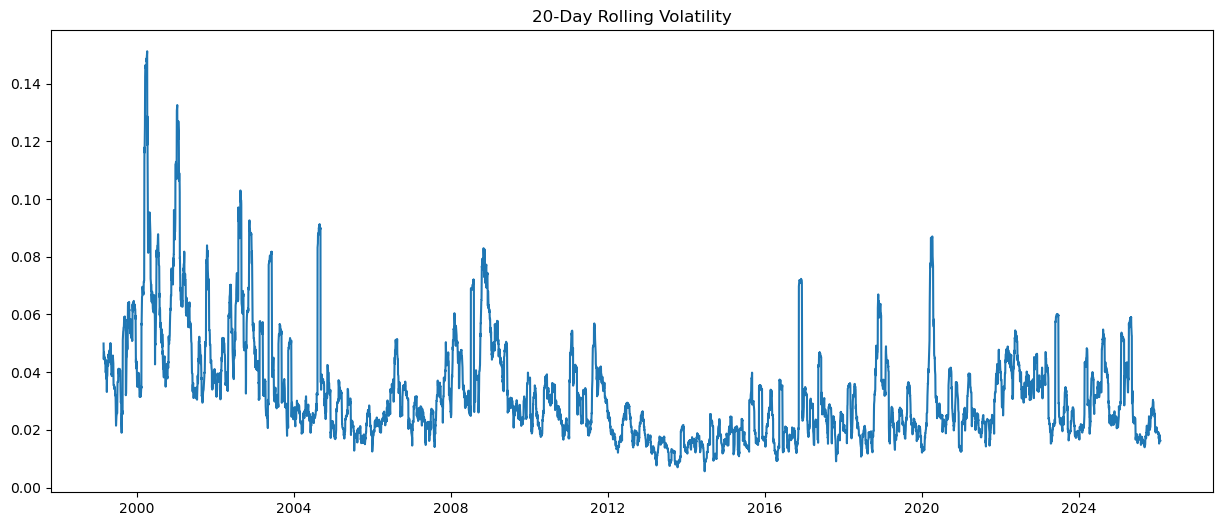

In [19]:
plt.figure(figsize=(15,6))

plt.plot(nvidia.index, nvidia['Volatility'])

plt.title('20-Day Rolling Volatility')

plt.show()

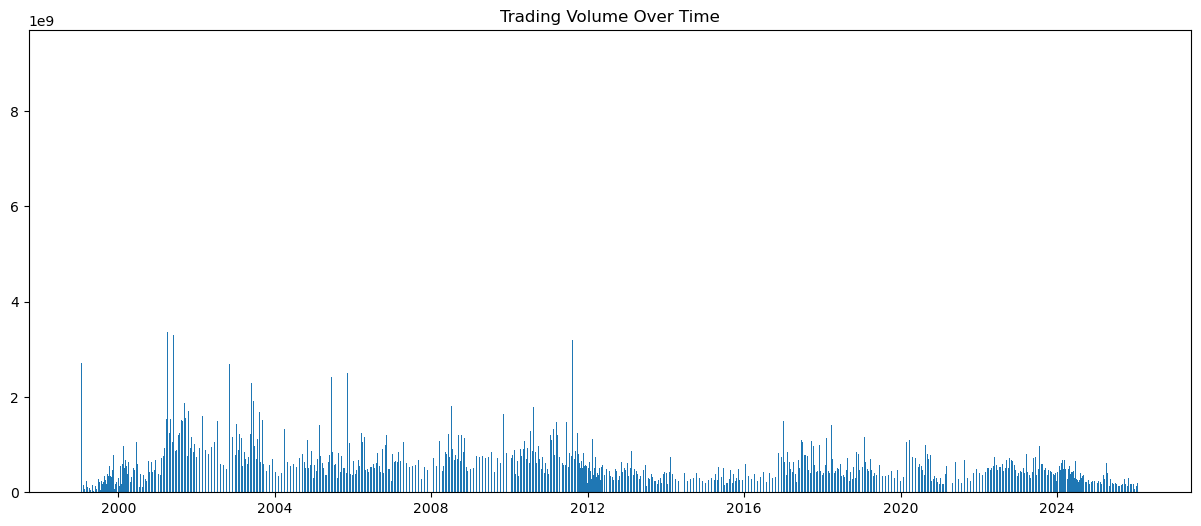

In [11]:
plt.figure(figsize=(15,6))

plt.bar(nvidia.index, nvidia['Volume'])

plt.title('Trading Volume Over Time')

plt.show()

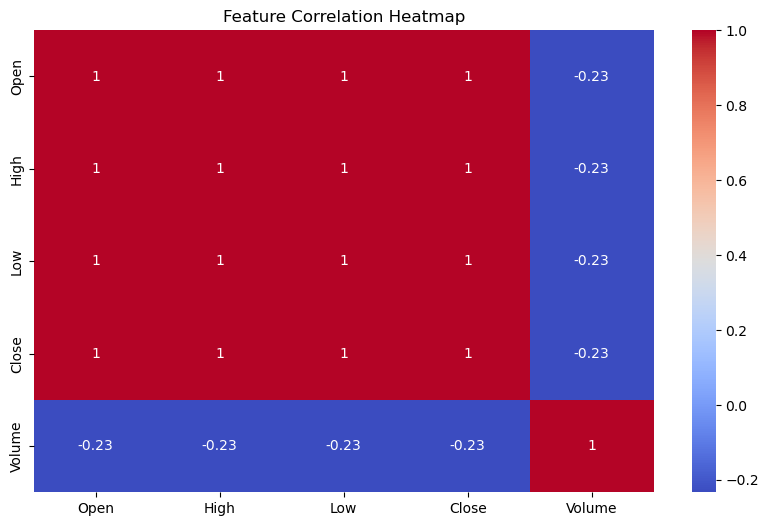

In [12]:
plt.figure(figsize=(10,6))

corr = nvidia[['Open','High','Low','Close','Volume']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Feature Correlation Heatmap')

plt.show()

## Candlestick Chart

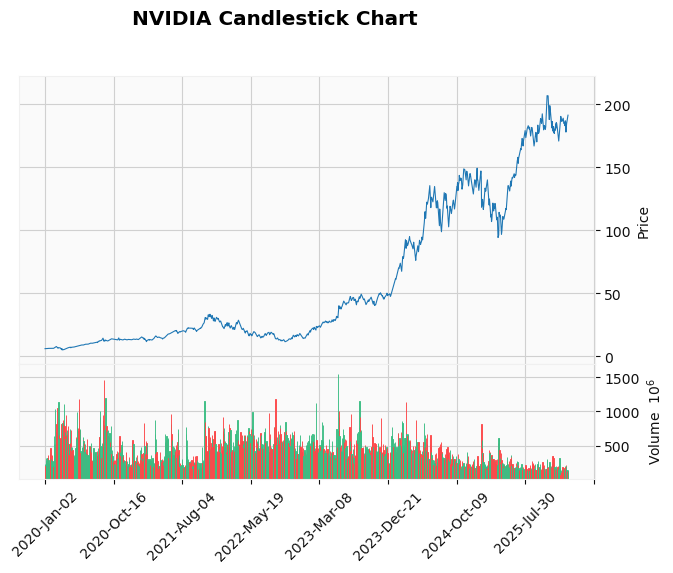

In [28]:
import mplfinance as mpf

mpf.plot(
    recent_data,
    type='line',
    volume=True,
    style='yahoo',
    title='NVIDIA Candlestick Chart'
)

### Outlier Detection

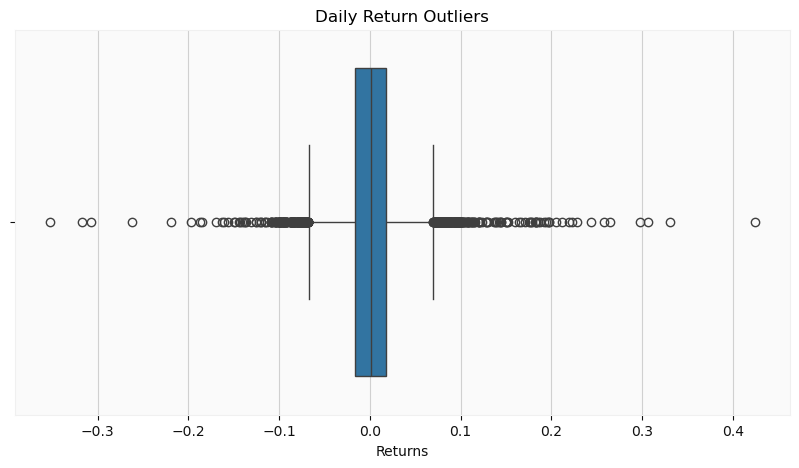

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(x=nvidia['Returns'])

plt.title('Daily Return Outliers')

plt.show()

1. NVIDIA stock shows strong long-term bullish momentum.

2. Volatility increased significantly between 2023 and 2025.

3. Trading volume spikes align with sharp price movements.

4. Moving averages confirm sustained upward trend.

5. Daily returns show high volatility with several extreme outliers.

In [34]:
nvidia.to_csv('nvidia_cleaned.csv', index = False)